Digits: (1797, 64), USPS: (9298, 256)
    SGD-MDS may not have converged: stress changed by 2.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
2025-11-04 16:16:08,709 - INFO - Epoch 0/100 - Recon Loss: 0.5111540 - Geo Loss: 0.0211787
2025-11-04 16:16:09,703 - INFO - Epoch 50/100 - Recon Loss: 0.1229168 - Geo Loss: 0.0000310
    SGD-MDS may not have converged: stress changed by 2.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
2025-11-04 16:16:30,349 - INFO - Epoch 0/100 - Recon Loss: 0.5344979 - Geo Loss: 0.0015211
2025-11-04 16:16:35,454 - INFO - Epoch 50/100 - Recon Loss: 0.1683729 - Geo Loss: 0.0000389


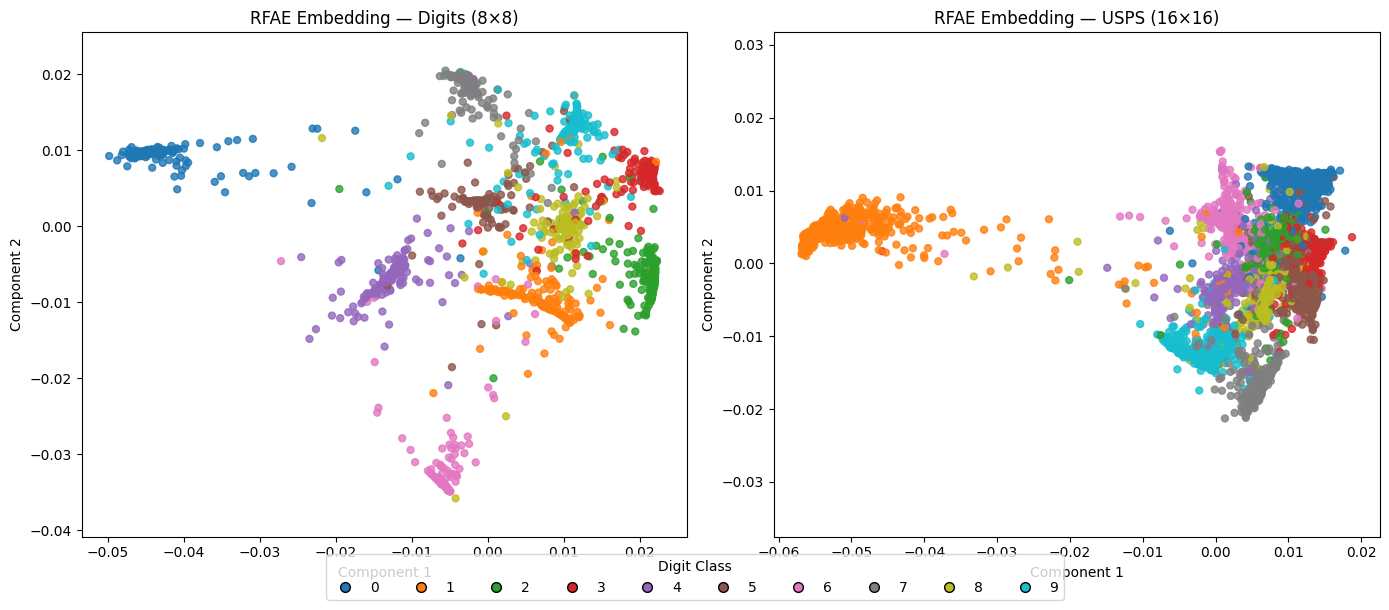

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, fetch_openml
from rfae import RFAE
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# 1️⃣ Load Digits and USPS datasets
# ---------------------------------------------------------
# Digits (8x8 grayscale)
digits = load_digits()
X_digits = digits.data.astype(float)
y_digits = digits.target

# USPS (16x16 grayscale, scaled to [0,1])
usps = fetch_openml("usps", version=2, as_frame=False)
X_usps = usps.data.astype(float)
y_usps = usps.target.astype(int)
X_usps = MinMaxScaler().fit_transform(X_usps)

print(f"Digits: {X_digits.shape}, USPS: {X_usps.shape}")

# ---------------------------------------------------------
# 2️⃣ Train separate RFAE models
# ---------------------------------------------------------
params = dict(random_state=42, device="mps", epochs=100, lam=0.001,
              embedder_params={'prox_method': 'rfgap', 'verbose': 0})

model_digits = RFAE(**params)
model_usps = RFAE(**params)

emb_digits = model_digits.fit_transform(X_digits, y_digits)
emb_usps = model_usps.fit_transform(X_usps, y_usps)

# ---------------------------------------------------------
# 3️⃣ Plot side-by-side embeddings (color = class label)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Digits ---
axes[0].scatter(
    emb_digits[:, 0], emb_digits[:, 1],
    c=y_digits, cmap="tab10", s=25, alpha=0.8
)
axes[0].set_title("RFAE Embedding — Digits (8×8)")
axes[0].set_xlabel("Component 1")
axes[0].set_ylabel("Component 2")
axes[0].axis("equal")

# --- USPS ---
axes[1].scatter(
    emb_usps[:, 0], emb_usps[:, 1],
    c=y_usps, cmap="tab10", s=25, alpha=0.8
)
axes[1].set_title("RFAE Embedding — USPS (16×16)")
axes[1].set_xlabel("Component 1")
axes[1].set_ylabel("Component 2")
axes[1].axis("equal")

# Common color legend
classes = np.unique(y_digits)
cmap = plt.get_cmap("tab10")
handles = [
    plt.Line2D([0], [0],
               marker="o",
               color="none",
               markerfacecolor=cmap(i % 10),
               markersize=7,
               label=str(cls))
    for i, cls in enumerate(classes)
]
fig.legend(handles=handles, title="Digit Class", loc="lower center",
           frameon=True, ncol=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()